In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [3]:
def scenario_payoff_grid(
    spot: float,
    stdev_move: float,
    n_steps: int,
    price_step: float,
    options: list
) -> pd.DataFrame:
    """
    Create a scenario analysis grid for the net payoff at expiration
    for a list of option positions, INCLUDING premiums, multipliers, etc.

    Parameters
    ----------
    spot : float
        Current underlying spot price.
    stdev_move : float
        Standard deviation of underlying moves (e.g., $10 for 1sigma if spot is 100).
    n_steps : int
        Number of 'steps' around the spot to compute. We'll go from -n_steps to +n_steps.
    price_step : float
        Increment for each price step. If you want integer steps, you can set this to 1.0.
    options : list of dict
        A list of option specifications. 
        Each dict can have keys:
          - 'symbol' (str): The underlying symbol, e.g. "SPY".
          - 'strike' (float): The option's strike price.
          - 'expiry' (str or date): A label or actual date for the option's expiration.
          - 'side' (str): 'long' or 'short'.
          - 'type' (str): 'call' or 'put'.
          - 'contracts' (int): Number of option contracts.
          - 'premium' (float): Premium paid/received per share.
          - 'multiplier' (int or float): How many shares per contract (e.g., 100 for SPY).
        Example:
          {
            'symbol': 'SPY',
            'strike': 400,
            'expiry': 'Jan',
            'side': 'long',
            'type': 'call',
            'contracts': 10,
            'premium': 5.0,
            'multiplier': 100
          }

    Returns
    -------
    DataFrame
        Rows:  Hypothetical underlying prices at expiration
        Cols:  Unique expiries found in 'options'
        Cells: Net payoff for the entire position at that expiry & underlying price.
    """
    
    # 1) Generate a range of underlying prices around the current spot
    min_price = spot - n_steps * stdev_move
    max_price = spot + n_steps * stdev_move

    scenario_prices = np.arange(min_price, max_price + price_step, price_step)
    
    # 2) Collect unique expiry labels
    expiries = sorted(list(set(opt['expiry'] for opt in options)))
    
    # 3) Prepare a structure to hold scenario results
    payoff_dict = {expiry: [] for expiry in expiries}
    
    # 4) Define a helper function to compute net payoff for one option at a given price
    def option_net_payoff(underlying_price, opt):
        """
        Compute the net payoff of one option at expiration, including:
         - Intrinsic value
         - Premium
         - Side (long/short)
         - Contracts
         - Multiplier
        """
        strike = opt['strike']
        side_multiplier = 1 if opt['side'].lower() == 'long' else -1
        contracts = opt['contracts']
        opt_type = opt['type'].lower()
        premium_per_share = opt.get('premium', 0.0)
        multiplier = opt.get('multiplier', 100)  # default to 100 if not provided
        
        # 4a) Intrinsic value per share
        if opt_type == 'call':
            intrinsic_per_share = max(0.0, underlying_price - strike)
        elif opt_type == 'put':
            intrinsic_per_share = max(0.0, strike - underlying_price)
        else:
            raise ValueError(f"Unknown option type {opt['type']}. Must be 'call' or 'put'.")

        # 4b) Scale intrinsic by multiplier (shares per contract)
        #     and subtract premium (also scaled by multiplier if side=long, or add if side=short).
        # net payoff per contract, in dollars:
        # = side_multiplier * (intrinsic - premium) * multiplier
        net_payoff_per_contract = side_multiplier * (
            (intrinsic_per_share - premium_per_share) * multiplier
        )
        
        # 4c) Multiply by number of contracts
        total_net_payoff = net_payoff_per_contract * contracts
        return total_net_payoff
    
    # 5) For each hypothetical underlying price
    for price in scenario_prices:
        # ...compute the payoff for each expiry by summing relevant options
        for expiry in expiries:
            expiry_payoff = sum(
                option_net_payoff(price, opt)
                for opt in options 
                if opt['expiry'] == expiry
            )
            payoff_dict[expiry].append(expiry_payoff)
    
    # 6) Build a DataFrame with rows=price scenario, columns=expiry
    df = pd.DataFrame(payoff_dict, index=scenario_prices)
    
    # Rename index/columns for clarity
    df.index.name = "Underlying_Price_at_Expiration"
    df.columns.name = "Expiry"
    
    return df

In [19]:
607-15

592

In [23]:
current_spot = 607.97
stdev_move = 50   # e.g. 1sigma is a $10 move around spot
n_steps = 1.1         # Analyze +/- 1sigma
price_step = 5.0    # We'll step in increments of $2

options_list = [
    {
        'symbol': 'SPY',
        'strike': 578,
        'expiry': '14Mar25', 
        'side': 'long', 
        'type': 'put', 
        'contracts': 1,
        'premium': 2.14,      #  points per share
        'multiplier': 100
    },
    {
        'symbol': 'SPY',
        'strike': 577,
        'expiry': '14Mar25', 
        'side': 'short', 
        'type': 'put', 
        'contracts': 1,
        'premium': 2.04,      #  points per share
        'multiplier': 100
    },
]

# Compute the scenario analysis table
df_scenarios = scenario_payoff_grid(
    spot=current_spot,
    stdev_move=stdev_move,
    n_steps=n_steps,
    price_step=price_step,
    options=options_list
)

array([[<AxesSubplot:title={'center':'14Mar25'}>]], dtype=object)

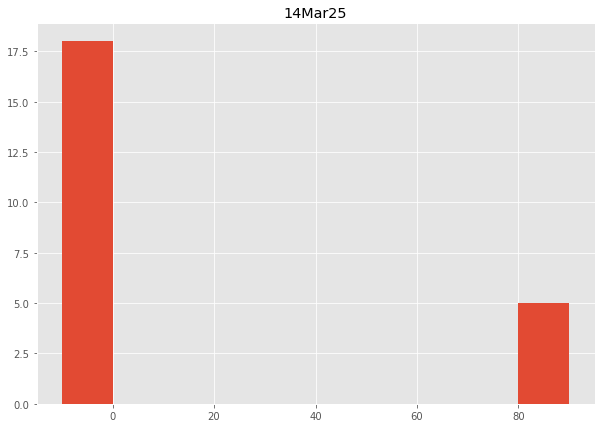

In [24]:
df_scenarios.hist(figsize=(10, 7))

In [30]:
df_scenarios[df_scenarios < 0].dropna().mean()

Expiry
14Mar25   -9.833333
dtype: float64

In [26]:
df_scenarios[df_scenarios<0].dropna().shape[0] / df_scenarios.dropna().shape[0]

0.9285714285714286

In [27]:
58 / current_spot

0.09830508474576272

In [28]:
19 / current_spot

0.03220338983050847

In [10]:
# expected loss for the linear trade assuming two scenarios
prob_linear_loss = 0.16
linear_loss_value = 58
expected_linear_loss = (prob_linear_loss * linear_loss_value) + ((1-prob_linear_loss) * 0)

# expected loss fro the nonlinear trade assuming two scenarios
prob_nonlinear_loss = 0.9
nonlinear_loss_value = 19
expected_nonlinear_loss = (prob_nonlinear_loss * nonlinear_loss_value) + ((1-prob_nonlinear_loss) * 0)

print(f"Expected Loss (pts): Linear={np.round(expected_linear_loss*-1, 2)}  Nonlinear={np.round(expected_nonlinear_loss*-1, 2)}")

Expected Loss (pts): Linear=-9.28  Nonlinear=-17.1


In [11]:
ratio_before_prob_adj = 58/19
ratio_after_prob_adj = 9.28/17.1

print(f"Ratios (linear/nonlinear): Before adj={np.round(ratio_before_prob_adj, 2)} After adj={np.round(ratio_after_prob_adj, 2)}")

Ratios (linear/nonlinear): Before adj=3.05 After adj=0.54
